**XAI Lib**: https://github.com/kdd-lab/XAI-Lib/tree/kode-refactoring <br>
This Jupyter is revised from (and other examples can be found at): https://github.com/pellungrobe/XAI_course_2024 

In [2]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn import metrics
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

We shall use a curated version of the COMPAS dataset <br>
https://raw.githubusercontent.com/PacktPublishing/Interpretable-Machine-Learning-with-Python/master/datasets/recidivism-risk_odsc.csv

We will use explanation methods to understand if there is something wrong with a model trained on this data.

## Data Prep


In [3]:
df = pd.read_csv("dataset/train_post_outlier.csv")

In [4]:
df = df.drop(columns="Unnamed: 0")

Compare the ground truth of whether defendents did recidivate (did_recid) versus the prediction for medium/high risk of recidivisim (compas_score).

In [5]:
rand = 9
np.random.seed(rand)

X = df.drop(columns=["rating_category", "isAdult"]).copy()
y = df["isAdult"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=rand
)

I will use catboost as model, since it has better performances on this data.

In [9]:
import catboost as cb

In [10]:
cb_mdl = cb.CatBoostClassifier(learning_rate=0.5, depth=7, random_seed=rand)

# Train Model
fitted_cb_mdl = cb_mdl.fit(X_train, y_train, verbose=False, plot=False)

# Evaluate Model
Y_pred = fitted_cb_mdl.predict(X_train)
print(classification_report(y_train, Y_pred))

Y_pred = fitted_cb_mdl.predict(X_test)
print(classification_report(y_test, Y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     90659
           1       1.00      1.00      1.00      1746

    accuracy                           1.00     92405
   macro avg       1.00      1.00      1.00     92405
weighted avg       1.00      1.00      1.00     92405

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     22660
           1       0.94      0.89      0.92       442

    accuracy                           1.00     23102
   macro avg       0.97      0.95      0.96     23102
weighted avg       1.00      1.00      1.00     23102



In [11]:
fitted_cb_mdl.get_feature_importance(cb.Pool(X_test, y_test), prettified=True)

,Feature Id,Importances
0,total_multimedia,1.746131e+01
1,release_decade,1.094744e+01
2,castNumber,9.452183e+00
3,runtimeMinutes,7.001059e+00
4,averageRating,6.402417e+00
5,word_count,5.439048e+00
6,companiesNumber,4.692786e+00
7,numRegions,4.498942e+00
8,titleType_movie,3.450303e+00
9,writerCredits,3.354904e+00


Let's start with a summary using SHAP. This can give us an overall idea of what is happening with our model

In [8]:
# pip install --force-reinstall numpy==2.2


In [85]:
import shap

In [12]:
shap_explainer = shap.TreeExplainer(fitted_cb_mdl)
shap_vals = shap_explainer.shap_values(X_test)
shap.summary_plot(shap_vals, X_test, plot_type="dot", show=False)
fig = plt.gcf()
fig.set_size_inches(8, 12)
plt.show()

NameError: name 'shap' is not defined

In [87]:
col_idx_to_name = dict(zip(list(range(0, X_test.shape[1])), X_test.columns))

# Get feature importance for interaction of features and use dictionary to replace indexes with names.
# Output just the top 10 interactions.
fitted_cb_mdl.get_feature_importance(
    cb.Pool(X_test, y_test), type="Interaction", prettified=True
).replace(col_idx_to_name).rename(
    columns={"First Feature Index": "Feature 1", "Second Feature Index": "Feature 2"}
).head(10)

,Feature 1,Feature 2,Interaction
0,runtimeMinutes,castNumber,2.654078
1,castNumber,averageRating,2.192519
2,runtimeMinutes,total_multimedia,2.107280
3,runtimeMinutes,averageRating,2.102550
4,castNumber,total_multimedia,2.000239
5,averageRating,total_multimedia,1.745970
6,release_decade,total_multimedia,1.679319
7,averageRating,word_count,1.340322
8,runtimeMinutes,titleType_video,1.315773
9,runtimeMinutes,word_count,1.194663


ValueError: x and y must be the same size

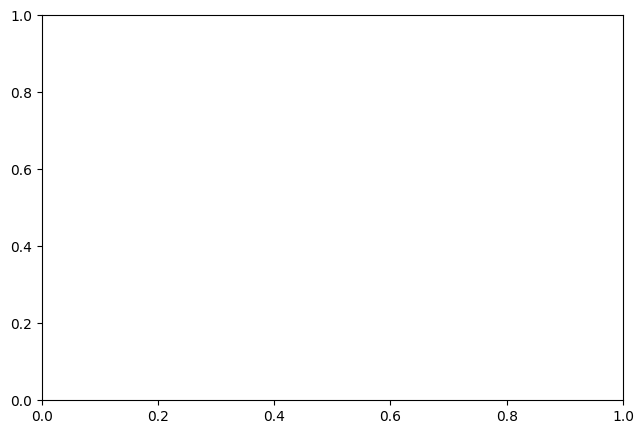

In [15]:
shap.dependence_plot(
    "runtimeMinutes",
    shap_vals,
    X_test,
    interaction_index="award_ratio",
    show=False,
    xmin="percentile(1)",
    xmax="percentile(99)",
    alpha=0.5,
)
fig = plt.gcf()
fig.set_size_inches(12, 8)
plt.show()

In [16]:
shap_explainer

In [17]:
shap.initjs()
shap.force_plot(shap_explainer.expected_value, shap_vals, X_test)

TypeError: In v0.20, force plot now requires the base value as the first parameter! Try shap.plots.force(explainer.expected_value, shap_values) or for multi-output models try shap.plots.force(explainer.expected_value[0], shap_values[..., 0]).

## Instance of Interest

Let's assume we are asked to look into the case of an African-American male defendent with 2 priors and no juvenile offenses, his data point is our instance of interest. To compare, let's also take similar points, except one is Hispanic and another one is Caucasian.

In [19]:
similarity = (
    (X_test.isAdult == 1)
    & (X_test.juv_fel_count == 0)
    & (X_test.juv_misd_count == 0)
    & (X_test.juv_other_count == 0)
    & (X_test["sex_Male"] == 1)
)

# The index of an African-American Defendent (the instance of interest).
aa_idx = X_test[
    (X_test.age == 23)
    & similarity
    & (X_test["race_African-American"] == 1)
    & (X_test["c_charge_degree_(F7)"] == 1)
].index[0]

# The index of two similar datapoints for and Hispanic and Caucasian defendents.
h_idx = X_test[
    (X_test.age == 23)
    & similarity
    & (X_test["race_Hispanic"] == 1)
    & (X_test["c_charge_degree_(F3)"] == 1)
].index[0]
c_idx = X_test[
    (X_test.age == 24)
    & similarity
    & (X_test["race_Caucasian"] == 1)
    & (X_test["c_charge_degree_(M1)"] == 1)
].index[0]

# Create boolean array to easily locate indexes in X_test dataframe.
instance_idxs = X_test.index.isin([aa_idx, h_idx, c_idx])

# Find instances in both X_test and recidivism2_df dataframes.
X_test_instances = X_test[instance_idxs]
X_instances = df[df.index.isin([aa_idx, h_idx, c_idx])]

# Create a dataframe joining y_test (the `compas_score` label), y_test_cb_pred (the predictions for Catboost),
# X_instances (to get `did_recid`) and X_test (for the rest of the features).
compare_df = (
    pd.concat(
        [
            pd.DataFrame(
                {"compas_score": y_test[instance_idxs]}, index=[c_idx, h_idx, aa_idx]
            ),
            pd.DataFrame(
                {"y_pred": Y_pred[instance_idxs]}, index=[c_idx, h_idx, aa_idx]
            ),
            pd.DataFrame(
                {"did_recid": np.array(X_instances["did_recid"])},
                index=[c_idx, h_idx, aa_idx],
            ),
            X_test_instances,
        ],
        axis=1,
    )
    .set_index([pd.Index(["Caucasian", "Hispanic", "African-American"])])
    .transpose()
    .style.apply(
        lambda x: [
            "background: yellow" if (x[2] != x[1] or x[2] != x[0]) else "" for i in x
        ],
        axis=1,
    )
    .apply(
        lambda x: [
            "background: lightgreen" if (x.name == "did_recid") else "" for i in x
        ],
        axis=1,
    )
)

compare_df

,Caucasian,Hispanic,African-American
compas_score,0,0,1
y_pred,0,0,1
did_recid,0,0,0
age,24,23,23
juv_fel_count,0,0,0
juv_misd_count,0,0,0
juv_other_count,0,0,0
priors_count,2,2,2
c_charge_degree_(CO3),False,False,False
c_charge_degree_(F1),False,False,False


Let us now use local explanation to understand what is happening to our case. Let's start with **SHAP**

## SHAP

I retrieve the index of my cases for my shapvalues

In [20]:
X_test_cont = X_test.reset_index(drop=True)
similarity = (
    (X_test_cont.priors_count == 2)
    & (X_test_cont.juv_fel_count == 0)
    & (X_test_cont.juv_misd_count == 0)
    & (X_test_cont.juv_other_count == 0)
    & (X_test_cont["sex_Male"] == 1)
)

# The index of an African-American Defendent (the instance of interest).
aa_idx_shap = X_test_cont[
    (X_test_cont.age == 23)
    & similarity
    & (X_test_cont["race_African-American"] == 1)
    & (X_test_cont["c_charge_degree_(F7)"] == 1)
].index[0]

# The index of two similar datapoints for and Hispanic and Caucasian defendents.
h_idx_shap = X_test_cont[
    (X_test_cont.age == 23)
    & similarity
    & (X_test_cont["race_Hispanic"] == 1)
    & (X_test_cont["c_charge_degree_(F3)"] == 1)
].index[0]
c_idx_shap = X_test_cont[
    (X_test_cont.age == 24)
    & similarity
    & (X_test_cont["race_Caucasian"] == 1)
    & (X_test_cont["c_charge_degree_(M1)"] == 1)
].index[0]

In [21]:
# Providing the names of the classes make for more readable explanations.
class_names = ["Low Risk", "Medium/High Risk"]

**African American**

In [22]:
shap.initjs()
shap.plots.force(shap_explainer.expected_value, shap_vals[aa_idx_shap], X_test.columns)

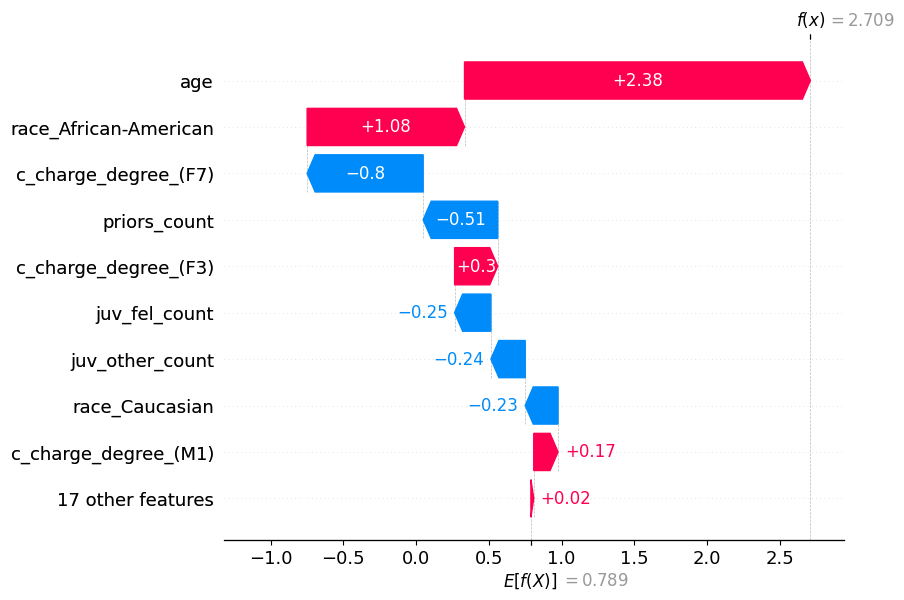

In [23]:
shap.plots._waterfall.waterfall_legacy(
    shap_explainer.expected_value,
    shap_vals[aa_idx_shap],
    feature_names=X_test.columns,
    max_display=10,
)

**Caucasian**

In [24]:
shap.initjs()
shap.plots.force(shap_explainer.expected_value, shap_vals[c_idx_shap], X_test.columns)

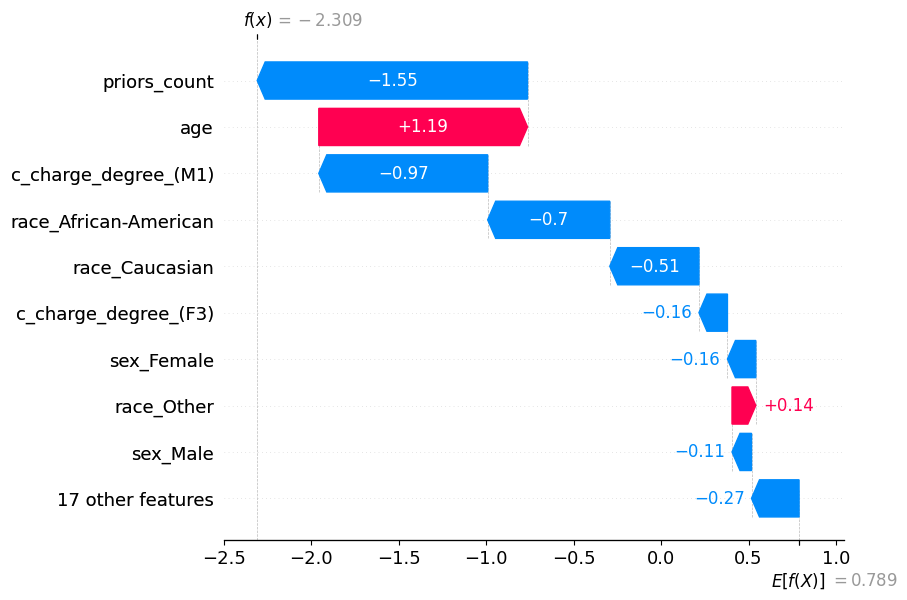

In [25]:
shap.plots._waterfall.waterfall_legacy(
    shap_explainer.expected_value,
    shap_vals[c_idx_shap],
    feature_names=X_test.columns,
    max_display=10,
)

**Hispanic**

In [26]:
shap.initjs()
shap.plots.force(shap_explainer.expected_value, shap_vals[h_idx_shap], X_test.columns)

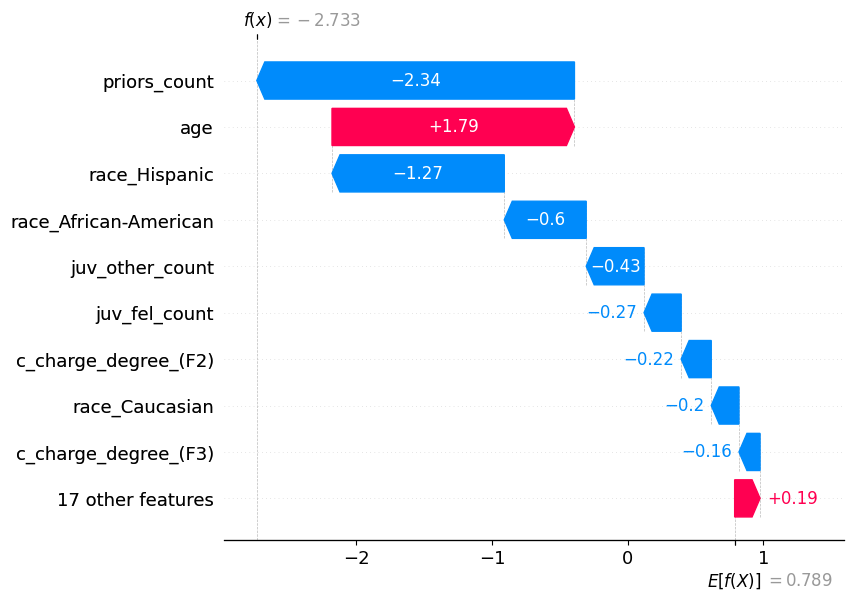

In [27]:
shap.plots._waterfall.waterfall_legacy(
    shap_explainer.expected_value,
    shap_vals[h_idx_shap],
    feature_names=X_test.columns,
    max_display=10,
)

## LORE 
from XAILib

In [18]:
%pip install XAI-Library

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 3.1 MB/s eta 0:00:00a 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached jsonschema-4.24.0-py3-none-any.whl.metadata (7.8 kB)
  Using cached networkx-3.5-py3-none-any.whl.metadata (6.3 kB)
  Using cached attrs-25.3.0-py3-none-any.whl.metadata (10 kB)
  Using cached jsonschema_specifications-2025.4.1-py3-none-any.whl.metadata (2.9 kB)
  Using cached referencing-0.36.2-py3-none-any.whl.metadata (2.8 kB)
  Using cached rpds_py-0.26.0-cp311-cp311-macosx_11_0_arm64.whl.metadata (4.2 kB)
  Using cached MarkupSafe-3.0.2-cp311-cp311-macosx_11_0_arm64.whl.metadata (4.0 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.2/731.2 kB 4.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.2/13.2 MB 4.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━

In [13]:
from xailib.models.sklearn_classifier_wrapper import sklearn_classifier_wrapper
from xailib.explainers.lore_explainer import LoreTabularExplainer
from xailib.explainers.shap_explainer_tab import ShapXAITabularExplainer

In [14]:
print(fitted_cb_mdl.feature_names_)

['runtimeMinutes', 'criticReviewsTotal', 'canHaveEpisodes', 'numRegions', 'castNumber', 'companiesNumber', 'averageRating', 'writerCredits', 'directorsCredits', 'quotesTotal', 'genre_Action', 'genre_Adventure', 'genre_Animation', 'genre_Comedy', 'genre_Crime', 'genre_Documentary', 'genre_Drama', 'genre_Family', 'genre_Romance', 'genre_Short', 'genre_Unknown', 'sound_Unknown', 'sound_dolby', 'sound_dolby_atmos', 'sound_dolby_digital', 'sound_dolby_sr', 'sound_dolby_stereo', 'sound_dts', 'sound_mono', 'sound_sdds', 'sound_silent', 'sound_stereo', 'continent_Africa', 'continent_Antarctica', 'continent_Asia', 'continent_Australia', 'continent_Europe', 'continent_North America', 'continent_Oceania', 'continent_Other', 'continent_South America', 'release_decade', 'word_count', 'award_ratio', 'total_multimedia', 'sentiment_Negative', 'sentiment_Neutral', 'sentiment_Positive', 'titleType_movie', 'titleType_short', 'titleType_tvEpisode', 'titleType_tvMiniSeries', 'titleType_tvMovie', 'titleType

In [15]:
bbox = sklearn_classifier_wrapper(fitted_cb_mdl)

In [16]:
print(X_train.columns.tolist())  # double check

['runtimeMinutes', 'criticReviewsTotal', 'canHaveEpisodes', 'numRegions', 'castNumber', 'companiesNumber', 'averageRating', 'writerCredits', 'directorsCredits', 'quotesTotal', 'genre_Action', 'genre_Adventure', 'genre_Animation', 'genre_Comedy', 'genre_Crime', 'genre_Documentary', 'genre_Drama', 'genre_Family', 'genre_Romance', 'genre_Short', 'genre_Unknown', 'sound_Unknown', 'sound_dolby', 'sound_dolby_atmos', 'sound_dolby_digital', 'sound_dolby_sr', 'sound_dolby_stereo', 'sound_dts', 'sound_mono', 'sound_sdds', 'sound_silent', 'sound_stereo', 'continent_Africa', 'continent_Antarctica', 'continent_Asia', 'continent_Australia', 'continent_Europe', 'continent_North America', 'continent_Oceania', 'continent_Other', 'continent_South America', 'release_decade', 'word_count', 'award_ratio', 'total_multimedia', 'sentiment_Negative', 'sentiment_Neutral', 'sentiment_Positive', 'titleType_movie', 'titleType_short', 'titleType_tvEpisode', 'titleType_tvMiniSeries', 'titleType_tvMovie', 'titleType

In [17]:
inst = X_train.iloc[[147]]
print("Instance ", inst)
print("True class ", y_train.iloc[147])
print("Predicted class ", bbox.predict(inst))


Instance          runtimeMinutes  criticReviewsTotal  canHaveEpisodes  numRegions  \
108878       -0.615385                 1.0            False         0.0   

        castNumber  companiesNumber  averageRating  writerCredits  \
108878       -0.75             -0.5           -1.0      -0.333333   

        directorsCredits  quotesTotal  ...  titleType_movie  titleType_short  \
108878               0.0          0.0  ...            False             True   

        titleType_tvEpisode  titleType_tvMiniSeries  titleType_tvMovie  \
108878                False                   False              False   

        titleType_tvSeries  titleType_tvShort  titleType_tvSpecial  \
108878               False              False                False   

        titleType_video  titleType_videoGame  
108878            False                False  

[1 rows x 58 columns]
True class  0
Predicted class  [0]


In [18]:
feature_names = df.drop(columns=["rating_category", "isAdult"]).columns

In [19]:
feature_names

Index(['runtimeMinutes', 'criticReviewsTotal', 'canHaveEpisodes', 'numRegions',
       'castNumber', 'companiesNumber', 'averageRating', 'writerCredits',
       'directorsCredits', 'quotesTotal', 'genre_Action', 'genre_Adventure',
       'genre_Animation', 'genre_Comedy', 'genre_Crime', 'genre_Documentary',
       'genre_Drama', 'genre_Family', 'genre_Romance', 'genre_Short',
       'genre_Unknown', 'sound_Unknown', 'sound_dolby', 'sound_dolby_atmos',
       'sound_dolby_digital', 'sound_dolby_sr', 'sound_dolby_stereo',
       'sound_dts', 'sound_mono', 'sound_sdds', 'sound_silent', 'sound_stereo',
       'continent_Africa', 'continent_Antarctica', 'continent_Asia',
       'continent_Australia', 'continent_Europe', 'continent_North America',
       'continent_Oceania', 'continent_Other', 'continent_South America',
       'release_decade', 'word_count', 'award_ratio', 'total_multimedia',
       'sentiment_Negative', 'sentiment_Neutral', 'sentiment_Positive',
       'titleType_movie', 't

In [20]:
explainer = ShapXAITabularExplainer(bbox, feature_names)
config = {"explainer": "tree", "X_train": X_train.iloc[0:100].values}
explainer.fit(config)


In [21]:
exp = explainer.explain(inst)

In [22]:
exp.plot_features_importance()

alt.VConcatChart(...)

In [24]:
imdb_lore = X_train.merge(y_train, right_index=True, left_index=True)

In [25]:
explainer = LoreTabularExplainer(bbox)
config = {"neigh_type": "rndgen", "size": 1000, "ocr": 0.1, "ngen": 10}
explainer.fit(imdb_lore, "isAdult", config)

In [26]:
exp = explainer.explain(inst)

AttributeError: 'DataFrame' object has no attribute 'reshape'

In [30]:
print("Instance ", X_test.loc[74898].values)
print("Predicted class ", fitted_cb_mdl.predict(X_test.loc[74898].values))
exp = explainer.explain(X_test.loc[74898].values)

Instance  [np.float64(-0.2115384615384615) np.float64(0.0) np.True_ np.float64(2.0)
 np.float64(-0.6875) np.float64(0.0) np.float64(-0.1176470588235295)
 np.float64(-0.3333333333333333) np.float64(-1.0) np.float64(0.0)
 np.int64(0) np.int64(0) np.int64(1) np.int64(0) np.int64(0) np.int64(0)
 np.int64(0) np.int64(0) np.int64(0) np.int64(0) np.int64(0) np.int64(1)
 np.int64(0) np.int64(0) np.int64(0) np.int64(0) np.int64(0) np.int64(0)
 np.int64(0) np.int64(0) np.int64(0) np.int64(0) np.int64(0) np.int64(0)
 np.int64(1) np.int64(0) np.int64(0) np.int64(0) np.int64(0) np.int64(0)
 np.int64(0) np.float64(0.0) np.float64(-0.5) np.float64(0.0)
 np.float64(0.0) np.False_ np.True_ np.False_ np.False_ np.False_
 np.False_ np.False_ np.False_ np.True_ np.False_ np.False_ np.False_
 np.False_]
Predicted class  0


In [29]:
print(X_test.index[:10])

Index([4970, 74898, 50130, 71444, 31815, 569, 45541, 59874, 30653, 53522], dtype='int64')


In [31]:
exp.plotRules()

In [32]:
exp.plotCounterfactualRules()

In [33]:
print("Instance ", X_test.loc[71444].values)
print("Predicted class ", fitted_cb_mdl.predict(X_test.loc[71444].values))
exp = explainer.explain(X_test.loc[71444].values)

Instance  [np.float64(-0.2115384615384615) np.float64(0.0) np.False_
 np.float64(-1.0) np.float64(-0.5625) np.float64(2.25)
 np.float64(0.823529411764706) np.float64(-0.3333333333333333)
 np.float64(0.0) np.float64(0.0) np.int64(0) np.int64(0) np.int64(0)
 np.int64(0) np.int64(0) np.int64(1) np.int64(0) np.int64(0) np.int64(0)
 np.int64(0) np.int64(0) np.int64(1) np.int64(0) np.int64(0) np.int64(0)
 np.int64(0) np.int64(0) np.int64(0) np.int64(0) np.int64(0) np.int64(0)
 np.int64(0) np.int64(0) np.int64(0) np.int64(0) np.int64(0) np.int64(0)
 np.int64(1) np.int64(0) np.int64(0) np.int64(0)
 np.float64(0.3333333333333333) np.float64(-1.0) np.float64(0.0)
 np.float64(0.0) np.False_ np.True_ np.False_ np.False_ np.False_ np.True_
 np.False_ np.False_ np.False_ np.False_ np.False_ np.False_ np.False_]
Predicted class  0


In [34]:
exp.plotRules()

In [35]:
exp.plotCounterfactualRules()

In [36]:
exp.getCounterExemplars()

## LIME
from XAI-Lib

In [37]:
from xailib.explainers.lime_explainer import LimeXAITabularExplainer

In [38]:
lime_cb_explainer = LimeXAITabularExplainer(bbox)

In [47]:
instance = X_test.iloc[[0]]  # or .loc[real_index] with double brackets
flat_instance = instance.values[0]  # extract the 1D vector
print(fitted_cb_mdl.predict_proba(flat_instance.reshape(1, -1)).shape)

(1, 2)


In [ ]:
# Pass to LIME explainer
exp = lime_cb_explainer.explain(flat_instance)

ValueError: Found array with dim 3, while dim <= 2 is required by Ridge.

In [44]:
probs = fitted_cb_mdl.predict_proba(instance.reshape(1, -1))
print(probs.shape)

(1, 2)


In [39]:
lime_cb_explainer.fit(imdb_lore, "isAdult", config={})

In [40]:
exp = lime_cb_explainer.explain(instance)

ValueError: Found array with dim 3, while dim <= 2 is required by Ridge.

In [46]:
exp.getFeaturesImportance()

[('priors_count', 0.20270332563864896),
 ('age', -0.15016845879480528),
 ('c_charge_degree_(M1)', -0.02738310740729573),
 ('race_African-American', 0.024101342788970758),
 ('c_charge_degree_(F7)', 0.022727749537672114),
 ('c_charge_degree_(F3)', 0.020806710808523615),
 ('race_Other', -0.020472543173564502),
 ('race_Caucasian', -0.01863632886418283),
 ('sex_Male', 0.0074123562209985824),
 ('sex_Female', 0.006407478563415055)]

In [47]:
exp.exp.show_in_notebook(predict_proba=True)

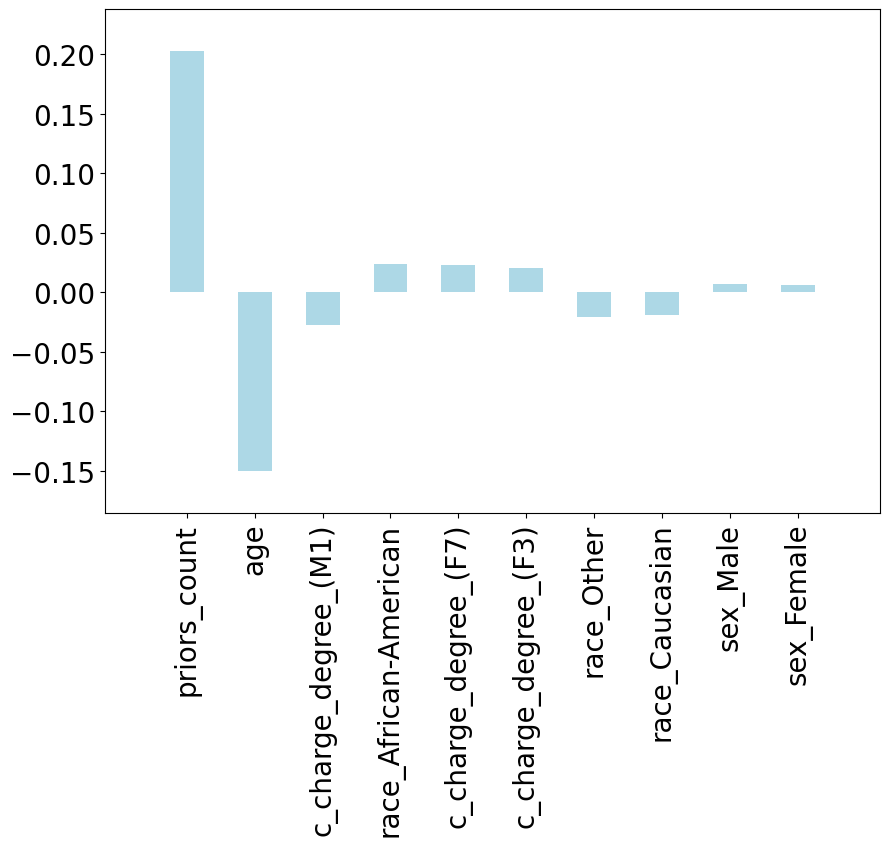

In [48]:
lime_cb_explainer.plot_lime_values(exp.exp.as_list(), 0, 10)

**Caucasian**

In [49]:
exp = lime_cb_explainer.explain(X_test.loc[c_idx].values)

In [50]:
exp.getFeaturesImportance()

[('priors_count', 0.2365838203776462),
 ('age', -0.16015866429028225),
 ('juv_fel_count', 0.04131295070147014),
 ('c_charge_degree_(M1)', -0.036292059256956916),
 ('race_African-American', 0.03222794633941987),
 ('c_charge_degree_(M2)', 0.012973898577333153),
 ('c_charge_degree_(F2)', -0.012866599883842872),
 ('sex_Female', 0.011953818328299193),
 ('sex_Male', -0.004817771873841996),
 ('c_charge_degree_(F3)', 0.003412398388891935)]

In [51]:
exp.exp.show_in_notebook(predict_proba=True)

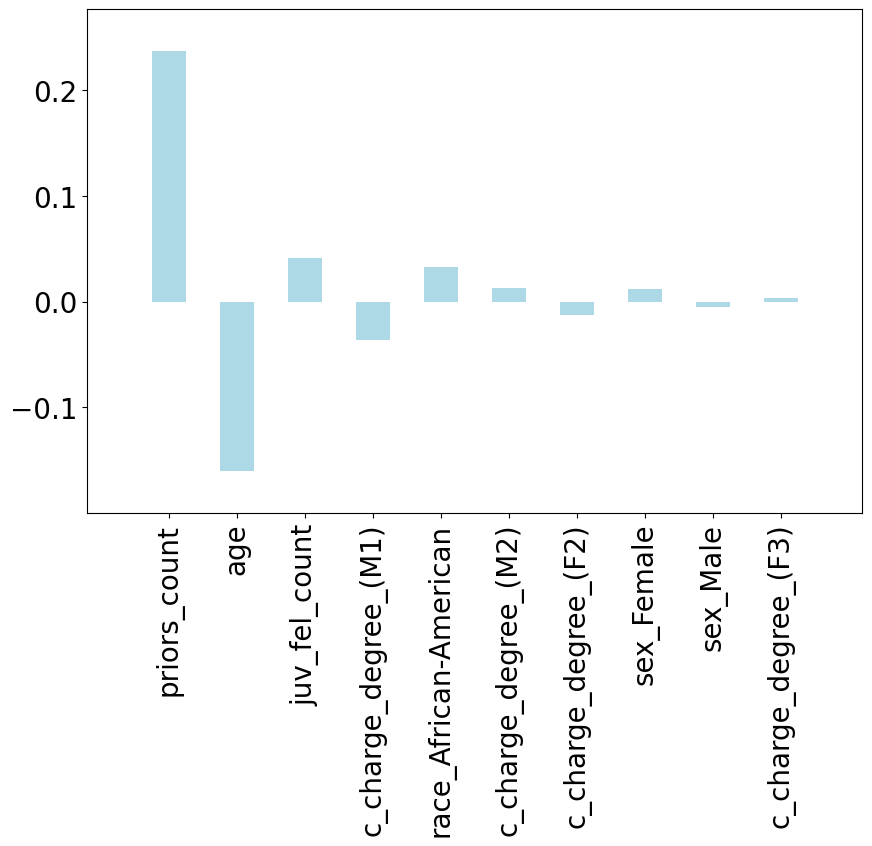

In [52]:
lime_cb_explainer.plot_lime_values(exp.exp.as_list(), 0, 10)

**Hispanic**

In [53]:
exp = lime_cb_explainer.explain(X_test.loc[h_idx].values)

In [54]:
exp.getFeaturesImportance()

[('priors_count', 0.23409955108245267),
 ('age', -0.16819926318108136),
 ('juv_fel_count', 0.05365536091829663),
 ('juv_misd_count', -0.02568211032400953),
 ('race_Hispanic', -0.022387291580475737),
 ('race_African-American', 0.0204079860249267),
 ('sex_Male', -0.019313333425495693),
 ('c_charge_degree_(M1)', -0.017424472975697585),
 ('c_charge_degree_(M2)', -0.014896944800837465),
 ('sex_Female', 0.009214327928310203)]

In [55]:
exp.exp.show_in_notebook(predict_proba=True)

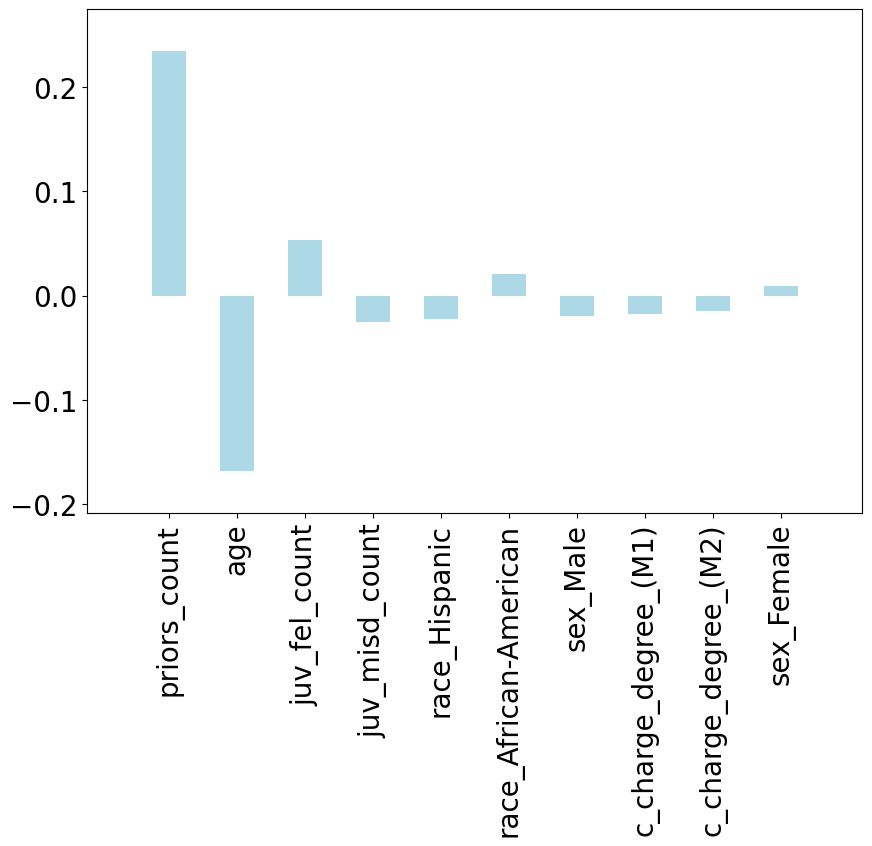

In [56]:
lime_cb_explainer.plot_lime_values(exp.exp.as_list(), 0, 10)